##**Analisis Faktor-Faktor yang Mempengaruhi Price dan Tip pada Taco Sales Dataset 2024–2025**

##**Import Dataset**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/beljar avd/taco_sales_(2024-2025).csv"
df = pd.read_csv(path)
df

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Taco Size,Taco Type,Toppings Count,Distance (km),Price ($),Tip ($),Weekend Order
0,770487,El Taco Loco,New York,01-08-2024 14:55,01-08-2024 15:36,41,Regular,Chicken Taco,5,3.01,9.25,2.22,False
1,671858,El Taco Loco,San Antonio,23-11-2024 17:11,23-11-2024 17:25,14,Regular,Beef Taco,1,6.20,4.25,3.01,True
2,688508,Taco Haven,Austin,21-11-2024 20:24,21-11-2024 21:02,38,Large,Pork Taco,2,20.33,7.00,0.02,False
3,944962,Spicy Taco House,Dallas,21-09-2024 06:43,21-09-2024 07:28,45,Regular,Chicken Taco,2,3.00,5.50,1.90,True
4,476417,Casa del Taco,San Antonio,24-07-2024 11:01,24-07-2024 11:16,15,Large,Pork Taco,0,24.34,4.50,1.14,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,164891,La Vida Taco,Austin,27-05-2024 11:12,27-05-2024 12:11,59,Large,Veggie Taco,2,20.04,7.00,2.80,False
996,232442,The Taco Stand,San Antonio,03-04-2025 20:51,03-04-2025 21:29,38,Regular,Fish Taco,0,13.69,3.00,1.38,False
997,251729,Urban Tacos,Houston,23-01-2025 05:33,23-01-2025 06:41,68,Regular,Pork Taco,2,4.07,5.50,2.00,False
998,940215,Taco Fiesta,San Antonio,05-09-2024 15:49,05-09-2024 16:38,49,Regular,Veggie Taco,5,14.56,9.25,1.89,False


##**BUSINESS UNDERSTANDING**

###**Business Objective**

Tujuan dari proyek ini adalah menganalisis pola penjualan taco berdasarkan data transaksi tahun 2024–2025 untuk membantu meningkatkan total pendapatan penjualan dan efektivitas operasional bisnis. Dengan memahami faktor-faktor yang memengaruhi harga dan tip, bisnis dapat menentukan strategi harga yang lebih tepat serta meningkatkan kualitas layanan.

###**Assess Situation**

Disaat ini bisnis taco memiliki data transaksi penjualan pada tahun 2024–2025 yang mencakup ukuran, jumlah topping, harga, tip, waktu pemesanan, lokasi, dan durasi pengiriman. Namun, data tersebut belum dianalisis untuk mengetahui faktor yang memengaruhi price dan tip, serta belum diketahui pola penjualan berdasarkan waktu dan lokasi. Jika tidak dianalisis, keputusan bisnis berisiko hanya berdasarkan asumsi.

###**Analytic Goals Project Plan**

Tujuan analisis ini adalah untuk mengidentifikasi faktor yang memengaruhi price dan tip pada penjualan taco.
Langkah yang dilakukan meliputi:
* Pembersihan dan pemeriksaan data.
* Analisis distribusi price dan tip.
* Analisis hubungan size dan topping count terhadap price.
* Perbandingan tip antara weekday dan weekend.
* Identifikasi lokasi dengan penjualan tertinggi.

##**Data Understanding**

###**Informasi Lanjutan**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Restaurant Name          1000 non-null   object        
 1   Location                 1000 non-null   object        
 2   Order Time               1000 non-null   datetime64[ns]
 3   Delivery Time            1000 non-null   datetime64[ns]
 4   Delivery Duration (min)  1000 non-null   int64         
 5   Taco Size                1000 non-null   object        
 6   Taco Type                1000 non-null   object        
 7   Toppings Count           1000 non-null   int64         
 8   Distance (km)            1000 non-null   float64       
 9   Price ($)                1000 non-null   float64       
 10  Tip ($)                  1000 non-null   float64       
 11  Weekend Order            1000 non-null   bool          
 12  Kategori Harga           1000 non-n

1. Order ID: Jumlah baris 1000, Tipe data int64, Deskripsi: ID unik setiap pesanan.
2. Restaurant Name: Jumlah baris 1000, Tipe data object, Deskripsi: Nama restoran tempat pesanan dibuat.
3. Location: Jumlah baris 1000, Tipe data object, Deskripsi: Lokasi atau area pengiriman.
4. Order Time: Jumlah baris 1000, Tipe data object, Deskripsi: Waktu pesanan dibuat.
5. Delivery Time: Jumlah baris 1000, Tipe data object, Deskripsi: Waktu pesanan diterima pelanggan.
6. Delivery Duration (min): Jumlah baris 1000, Tipe data int64, Deskripsi: Lama pengiriman dalam menit.
7. Taco Size: Jumlah baris 1000, Tipe data object, Deskripsi: Ukuran taco (Regular atau Large).
8. Taco Type: Jumlah baris 1000, Tipe data object, Deskripsi: Jenis atau varian taco.
9. Toppings Count: Jumlah baris 1000, Tipe data int64, Deskripsi: Jumlah topping pada taco.
10. Distance (km): Jumlah baris 1000, Tipe data float64, Deskripsi: Jarak pengiriman dalam kilometer.
11. Price ($):jumlah baris 1000, Tipe data float64, Deskripsi: Harga pesanan dalam dolar.

12. Tip ($): Jumlah baris 1000, Tipe data float64, Deskripsi: Jumlah tip yang diberikan pelanggan.
13. Weekend Order: Jumlah baris 1000, Tipe data bool, Deskripsi: Menunjukkan apakah pesanan dilakukan saat akhir pekan (True/False).



###**Statistik Deskriptif**

In [ ]:
df.describe(include='all')

,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Taco Size,Taco Type,Toppings Count,Distance (km),Price ($),Tip ($),Weekend Order,Kategori Harga
count,1000,1000,1000,1000,1000.00000,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000
unique,10,10,NaN,NaN,NaN,2,5,NaN,NaN,NaN,NaN,2,3
top,Urban Tacos,Chicago,NaN,NaN,NaN,Regular,Chicken Taco,NaN,NaN,NaN,NaN,False,Murah
freq,117,116,NaN,NaN,NaN,502,218,NaN,NaN,NaN,NaN,725,416
mean,NaN,NaN,2024-09-28 13:28:54.480000,2024-09-28 13:40:57.480000,50.93000,NaN,NaN,2.529000,13.073420,6.908250,1.806016,NaN,NaN
min,NaN,NaN,2024-01-01 18:39:00,2024-01-01 19:48:00,10.00000,NaN,NaN,0.000000,0.510000,3.000000,0.010000,NaN,NaN
25%,NaN,NaN,2024-05-16 07:15:30,2024-05-16 11:58:15,30.00000,NaN,NaN,1.000000,6.972500,4.500000,0.907500,NaN,NaN
50%,NaN,NaN,2024-09-14 02:31:30,2024-09-14 03:53:00,53.00000,NaN,NaN,3.000000,13.200000,6.750000,1.760000,NaN,NaN
75%,NaN,NaN,2025-01-27 05:15:30,2025-01-27 06:24:30,71.00000,NaN,NaN,4.000000,19.242500,9.250000,2.520000,NaN,NaN
max,NaN,NaN,2025-12-02 16:55:00,2025-12-02 17:36:00,90.00000,NaN,NaN,5.000000,24.980000,10.750000,4.938750,NaN,NaN


Secara keseluruhan, distribusi harga dan tip relatif stabil tanpa nilai ekstrem yang mencolok. Mayoritas pelanggan memilih ukuran Regular dan jenis Chicken Taco, serta sebagian besar pesanan dilakukan pada hari biasa.

###**Cek Tipe Data Pada Setiap Kolom**

In [ ]:
df.dtypes

,0
Restaurant Name,object
Location,object
Order Time,datetime64[ns]
Delivery Time,datetime64[ns]
Delivery Duration (min),int64
Taco Size,object
Taco Type,object
Toppings Count,int64
Distance (km),float64
Price ($),float64


Sebagian besar tipe data sudah sesuai dengan karakteristik variabelnya. Namun, kolom Order Time dan Delivery Time masih bertipe object sehingga perlu dikonversi ke datetime agar dapat digunakan untuk analisis berbasis waktu seperti identifikasi jam sibuk dan durasi pengiriman.

###**Cek Incosistent Values Pada Setiap Kolom**

Dari hasil pengecekan di setiap kolom, tidak ditemukan penulisan yang berbeda-beda atau typo. Semua data sudah konsisten dan tidak ada spasi berlebih. Jadi bisa disimpulkan kalau datanya sudah rapi dan siap untuk dianalisis lebih lanjut.

In [ ]:
print(df['Order ID'].unique())

KeyError: 'Order ID'

In [ ]:
print(df['Restaurant Name'].unique())

In [ ]:
print(df['Location'].unique())

In [ ]:
print(df['Order Time'].unique())

In [ ]:
print(df['Delivery Time'].unique())

In [ ]:
print(df['Delivery Duration (min)'].unique())

In [ ]:
print(df['Taco Size'].unique())

In [ ]:
print(df['Taco Type'].unique())

In [ ]:
print(df['Toppings Count'].unique())

In [ ]:
print(df['Distance (km)'].unique())

In [ ]:
print(df['Price ($)'].unique())

In [ ]:
print(df['Tip ($)'].unique())

In [ ]:
print(df['Weekend Order'].unique())

###**Missing Values**

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

Disini terlihat tidak ada data missing values.

###**Duplicated Values**

In [ ]:
df[df.duplicated()]

Disini terlihat tidak ada data yang terduplikasi.

###**Outliers**

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Disini terlihat ada sedikit nilai yang berbeda atau adanya outliers pada kolom tip yaitu sebesar 0,3%

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Tip ($)'])
plt.title('Boxplot of Tip ($)')
plt.ylabel('Tip ($)')
plt.show()

Boxplot pada kolom Tip ($) menunjukkan bahwa mayoritas tip berada pada kisaran 1–2.5 dolar dengan median sekitar 1.9 dolar. Terdapat satu outlier yang menunjukkan adanya tip yang jauh lebih tinggi dibanding transaksi lainnya.

##**EDA**

###**Comparison (Perbandingan)**

Meskipun taco ukuran Large memiliki rata-rata harga lebih tinggi dibandingkan Regular, perbedaannya tidak terlalu besar sehingga ukuran bukan faktor dominan dalam menentukan price.

/tmp/ipykernel_595/401179643.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_size.index, y=avg_price_size.values, palette='viridis')


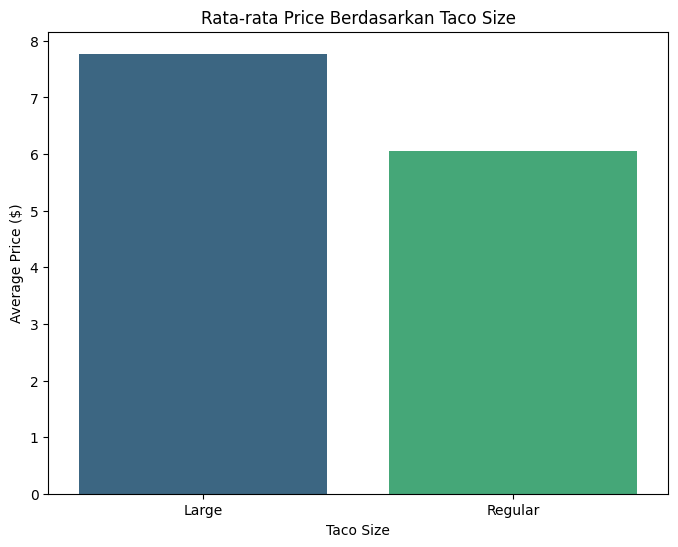

In [ ]:
avg_price_size = df.groupby('Taco Size')['Price ($)'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=avg_price_size.index, y=avg_price_size.values, palette='viridis')
plt.title('Rata-rata Price Berdasarkan Taco Size')
plt.xlabel('Taco Size')
plt.ylabel('Average Price ($)')
plt.show()

###**Composition (Komposisi)**

Diagram menunjukkan bahwa Chicken Taco memiliki kontribusi revenue tertinggi, sedangkan Beef Taco terendah. Namun secara keseluruhan, kontribusi antar jenis taco relatif seimbang tanpa dominasi yang signifikan.

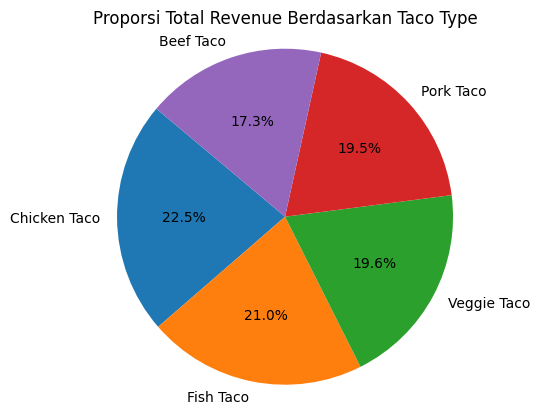

In [ ]:
sales_by_type = df.groupby('Taco Type')['Price ($)'].sum().sort_values(ascending=False)
plt.figure()
plt.pie(sales_by_type.values,
        labels=sales_by_type.index,
        autopct='%1.1f%%',
        startangle=140)

plt.title('Proporsi Total Revenue Berdasarkan Taco Type')
plt.axis('equal')
plt.show()

###**Distribution (Distribusi)**

Tingginya frekuensi pada beberapa rentang harga menunjukkan bahwa harga tersebut merupakan harga yang paling banyak dipilih pelanggan. Namun, tidak terdapat nilai harga yang menyimpang secara ekstrem, sehingga distribusi harga tergolong stabil.

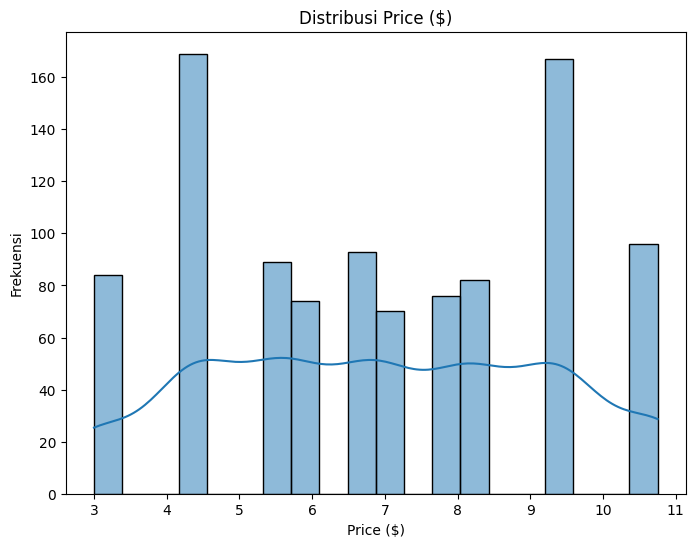

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Price ($)'], bins=20, kde=True)

plt.title('Distribusi Price ($)')
plt.xlabel('Price ($)')
plt.ylabel('Frekuensi')
plt.show()

###**Relationship (Hubungan)**

Menurut saya relasi antar variabel sudah cukup baik. Namun, pada bagian delivery duration agak kurang berkolerasi dengan yang lain karna terlihat meiliki nilai negatif.

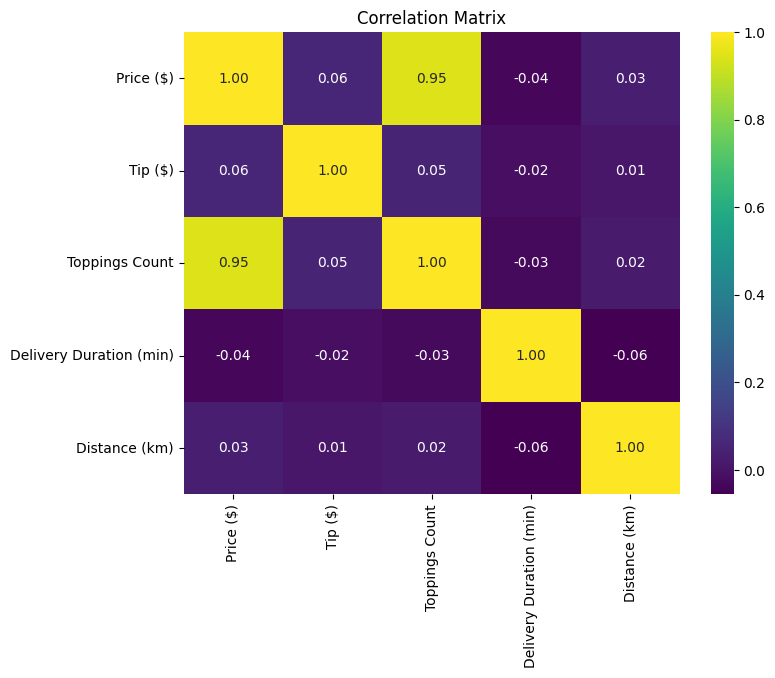

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[['Price ($)', 'Tip ($)', 'Toppings Count',
        'Delivery Duration (min)', 'Distance (km)']].corr(),
    annot=True,
    cmap='viridis',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

##**DATA PREPARATION**

###**Tipe Data**

Kolom Order Time dan Delivery Time diubah menjadi tipe datetime agar dapat dianalisis berdasarkan waktu.

In [ ]:
df.dtypes

,0
Order ID,int64
Restaurant Name,object
Location,object
Order Time,object
Delivery Time,object
Delivery Duration (min),int64
Taco Size,object
Taco Type,object
Toppings Count,int64
Distance (km),float64


In [ ]:
df['Order Time'] = pd.to_datetime(df['Order Time'], format="mixed")
df['Delivery Time'] = pd.to_datetime(df['Delivery Time'], format="mixed")

In [ ]:
df.dtypes

,0
Order ID,int64
Restaurant Name,object
Location,object
Order Time,datetime64[ns]
Delivery Time,datetime64[ns]
Delivery Duration (min),int64
Taco Size,object
Taco Type,object
Toppings Count,int64
Distance (km),float64


###**Incosistent Values**

Dari hasil pengecekan di setiap kolom, tidak ditemukan penulisan yang berbeda-beda atau typo. Semua data sudah konsisten dan tidak ada spasi berlebih. Jadi bisa disimpulkan kalau datanya sudah rapi dan siap untuk dianalisis lebih lanjut.

###**Missing Values**

Tidak ada data missing values pada data ini.

###**Duplicated Values**

Tidak ada data yang terduplikasi.

###**Outliers**


Datanya tidak dihapus, hanya dibatasi supaya nilainya tidak terlalu ekstrem dan tidak mengganggu hasil analisis.

In [ ]:
Q1 = df['Tip ($)'].quantile(0.25)
Q3 = df['Tip ($)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Tip ($)'] = df['Tip ($)'].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Order ID,0.0
Delivery Duration (min),0.0
Toppings Count,0.0
Distance (km),0.0
Price ($),0.0
Tip ($),0.0


###**Construct Data**

Kolom Kategori Harga dibuat untuk mempermudah segmentasi harga dalam analisis strategi penentuan harga dan promosi.

In [ ]:
def kategori_harga(price):
    if price < 6:
        return 'Murah'
    elif price <= 8:
        return 'Sedang'
    else:
        return 'Mahal'

df['Kategori Harga'] = df['Price ($)'].apply(kategori_harga)

In [ ]:
df

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Taco Size,Taco Type,Toppings Count,Distance (km),Price ($),Tip ($),Weekend Order,Kategori Harga
0,770487,El Taco Loco,New York,2024-01-08 14:55:00,2024-01-08 15:36:00,41,Regular,Chicken Taco,5,3.01,9.25,2.22,False,Mahal
1,671858,El Taco Loco,San Antonio,2024-11-23 17:11:00,2024-11-23 17:25:00,14,Regular,Beef Taco,1,6.20,4.25,3.01,True,Murah
2,688508,Taco Haven,Austin,2024-11-21 20:24:00,2024-11-21 21:02:00,38,Large,Pork Taco,2,20.33,7.00,0.02,False,Sedang
3,944962,Spicy Taco House,Dallas,2024-09-21 06:43:00,2024-09-21 07:28:00,45,Regular,Chicken Taco,2,3.00,5.50,1.90,True,Murah
4,476417,Casa del Taco,San Antonio,2024-07-24 11:01:00,2024-07-24 11:16:00,15,Large,Pork Taco,0,24.34,4.50,1.14,False,Murah
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,164891,La Vida Taco,Austin,2024-05-27 11:12:00,2024-05-27 12:11:00,59,Large,Veggie Taco,2,20.04,7.00,2.80,False,Sedang
996,232442,The Taco Stand,San Antonio,2025-03-04 20:51:00,2025-03-04 21:29:00,38,Regular,Fish Taco,0,13.69,3.00,1.38,False,Murah
997,251729,Urban Tacos,Houston,2025-01-23 05:33:00,2025-01-23 06:41:00,68,Regular,Pork Taco,2,4.07,5.50,2.00,False,Murah
998,940215,Taco Fiesta,San Antonio,2024-05-09 15:49:00,2024-05-09 16:38:00,49,Regular,Veggie Taco,5,14.56,9.25,1.89,False,Mahal


###**Data Reduction**

Kolom Order ID dihapus karena hanya berfungsi sebagai identitas unik transaksi dan tidak memiliki pengaruh terhadap analisis harga, tip, maupun pola transaksi.

In [ ]:
df = df.drop(columns=['Order ID'])

In [ ]:
df

,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Taco Size,Taco Type,Toppings Count,Distance (km),Price ($),Tip ($),Weekend Order,Kategori Harga
0,El Taco Loco,New York,2024-01-08 14:55:00,2024-01-08 15:36:00,41,Regular,Chicken Taco,5,3.01,9.25,2.22,False,Mahal
1,El Taco Loco,San Antonio,2024-11-23 17:11:00,2024-11-23 17:25:00,14,Regular,Beef Taco,1,6.20,4.25,3.01,True,Murah
2,Taco Haven,Austin,2024-11-21 20:24:00,2024-11-21 21:02:00,38,Large,Pork Taco,2,20.33,7.00,0.02,False,Sedang
3,Spicy Taco House,Dallas,2024-09-21 06:43:00,2024-09-21 07:28:00,45,Regular,Chicken Taco,2,3.00,5.50,1.90,True,Murah
4,Casa del Taco,San Antonio,2024-07-24 11:01:00,2024-07-24 11:16:00,15,Large,Pork Taco,0,24.34,4.50,1.14,False,Murah
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,La Vida Taco,Austin,2024-05-27 11:12:00,2024-05-27 12:11:00,59,Large,Veggie Taco,2,20.04,7.00,2.80,False,Sedang
996,The Taco Stand,San Antonio,2025-03-04 20:51:00,2025-03-04 21:29:00,38,Regular,Fish Taco,0,13.69,3.00,1.38,False,Murah
997,Urban Tacos,Houston,2025-01-23 05:33:00,2025-01-23 06:41:00,68,Regular,Pork Taco,2,4.07,5.50,2.00,False,Murah
998,Taco Fiesta,San Antonio,2024-05-09 15:49:00,2024-05-09 16:38:00,49,Regular,Veggie Taco,5,14.56,9.25,1.89,False,Mahal


##**VISUALISASI**

###**Bar Chart**

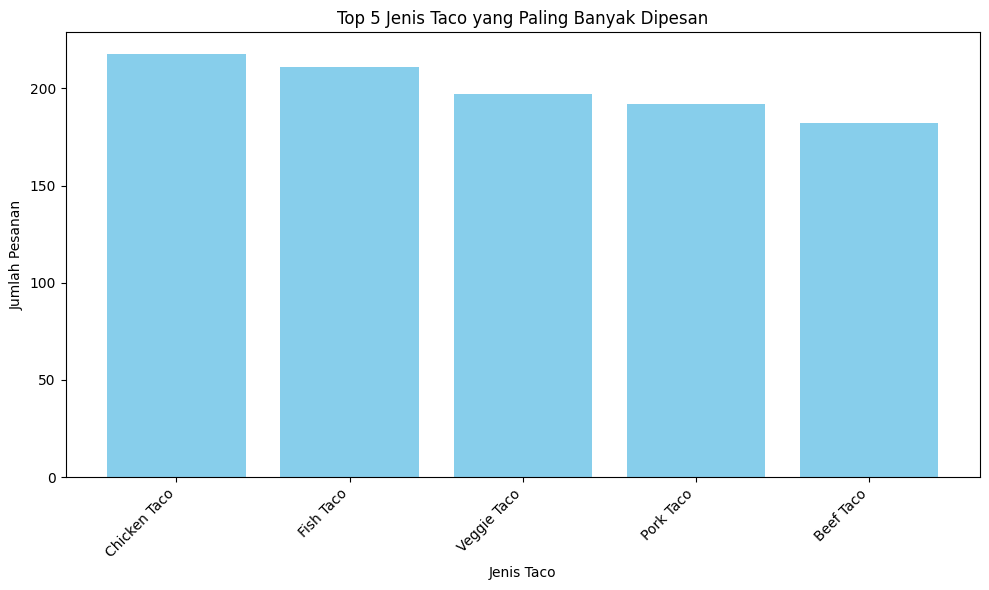

In [ ]:
VARIABEL = df['Taco Type'].value_counts().head(5).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(VARIABEL.index, VARIABEL.values, color='skyblue')
plt.xlabel('Jenis Taco')
plt.ylabel('Jumlah Pesanan')
plt.title('Top 5 Jenis Taco yang Paling Banyak Dipesan')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Dari grafik ini terlihat bahwa Chicken Taco merupakan jenis taco yang paling sering dipesan, diikuti oleh Fish Taco, Veggie Taco, Pork Taco, dan Beef Taco. Hal ini menunjukkan bahwa pelanggan lebih menyukai varian Chicken Taco dibandingkan jenis lainnya. Oleh karena itu, restoran dapat memastikan ketersediaan bahan untuk menu tersebut agar tetap tersedia saat permintaan tinggi, serta menjadikannya sebagai menu unggulan atau bagian dari promosi untuk meningkatkan penjualan.

###**Pie Chart**

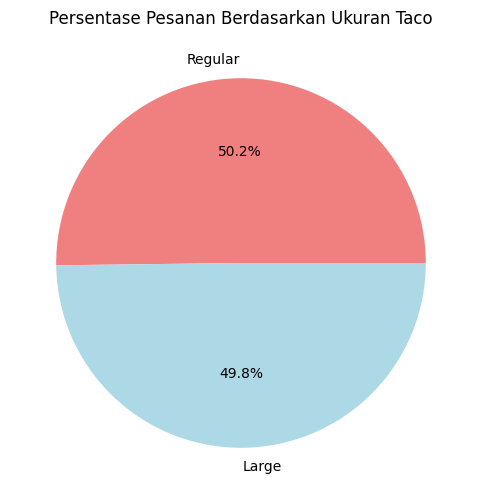

In [ ]:
plt.figure(figsize=(10, 6)) # ukuran
plt.pie(df['Taco Size'].value_counts(), labels=df['Taco Size'].value_counts().index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
plt.title('Persentase Pesanan Berdasarkan Ukuran Taco') # Judul
plt.show()

Dari pie chart ini terlihat bahwa persentase pesanan Regular dan Large hampir seimbang, dengan Regular sekitar 50.2% dan Large sekitar 49.8%. Hal ini menunjukkan bahwa pelanggan tidak memiliki perbedaan preferensi yang terlalu signifikan terhadap ukuran taco. Oleh karena itu, restoran perlu memastikan ketersediaan kedua ukuran taco tersebut tetap seimbang agar dapat memenuhi permintaan pelanggan dengan baik.

###**Line Chart**

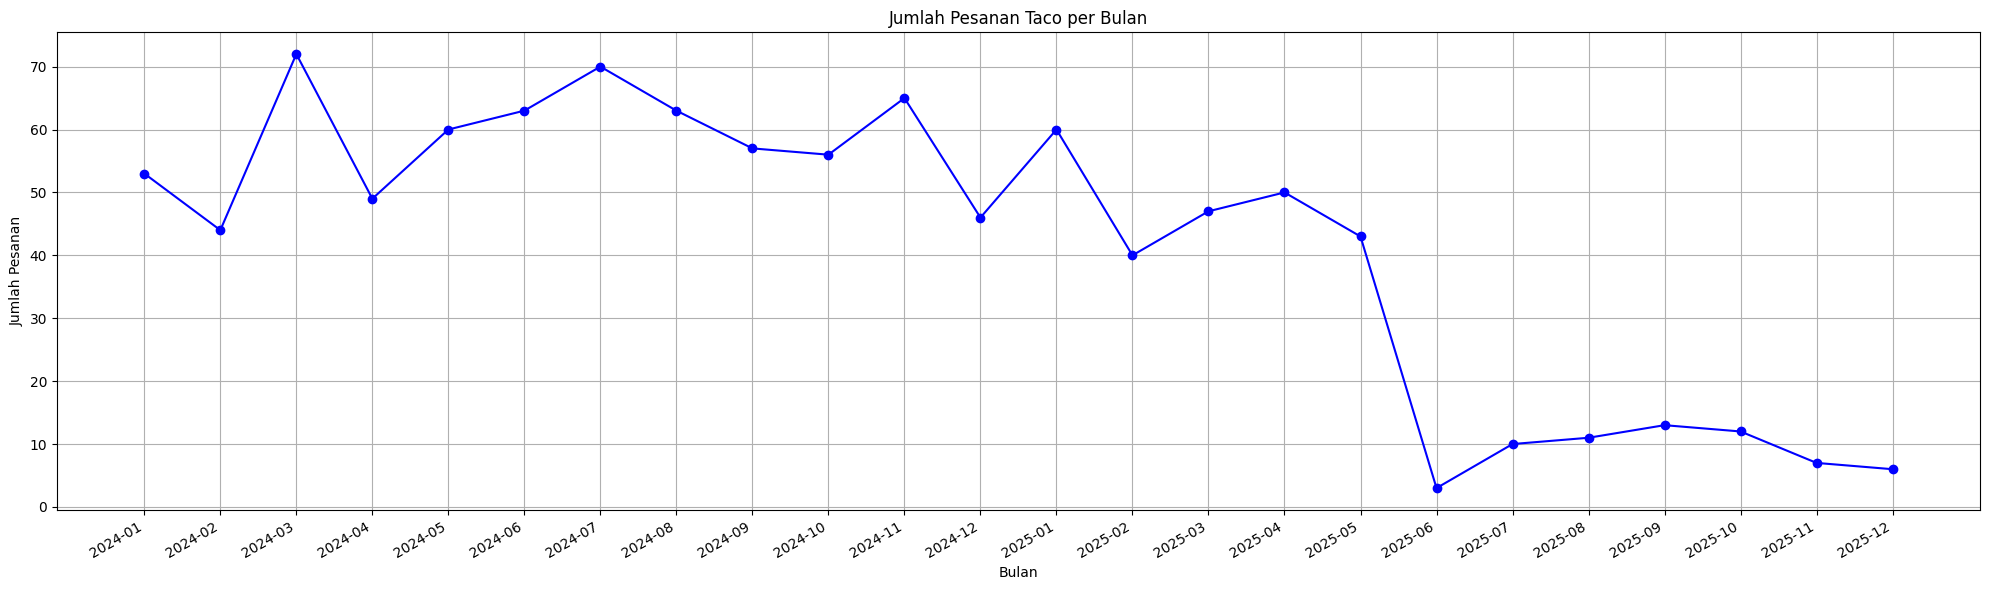

In [ ]:
df['Order Time'] = pd.to_datetime(df['Order Time'])

pesanan_bulanan = df.groupby(df['Order Time'].dt.to_period('M')).size()

plt.figure(figsize=(20, 6))
plt.plot(pesanan_bulanan.index.astype(str), pesanan_bulanan.values, marker='o', color='blue')
plt.title('Jumlah Pesanan Taco per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Pesanan')
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

Dari line chart ini terlihat bahwa jumlah pesanan taco mengalami perubahan dari waktu ke waktu. Pada beberapa waktu jumlah pesanan meningkat, sedangkan pada waktu lainnya mengalami penurunan. Hal ini menunjukkan bahwa permintaan taco tidak selalu stabil. Oleh karena itu, restoran dapat menyesuaikan persediaan bahan dan menyiapkan strategi promosi pada saat permintaan meningkat agar kebutuhan pelanggan tetap dapat terpenuhi.

###**Histrogram**

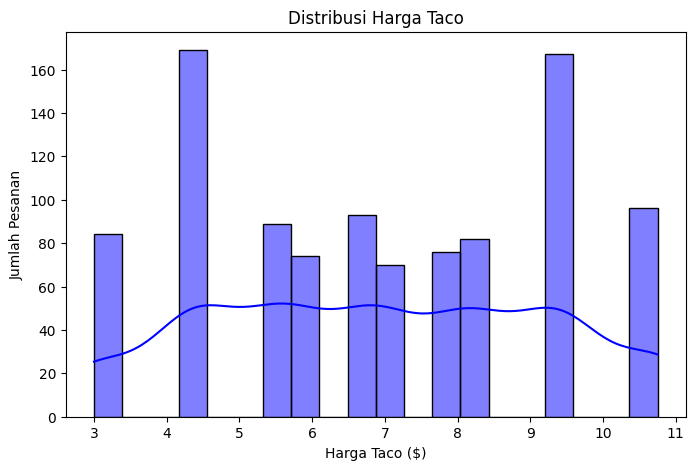

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Price ($)'], bins=20, kde=True, color='blue')
plt.title('Distribusi Harga Taco')
plt.xlabel('Harga Taco ($)')
plt.ylabel('Jumlah Pesanan')
plt.show()

Dari histogram ini terlihat bahwa harga taco yang paling sering muncul berada di sekitar 4.50 dan 9.50. Hal ini menunjukkan bahwa pelanggan cukup sering memesan taco pada kedua kisaran harga tersebut. Oleh karena itu, restoran dapat memastikan menu pada rentang harga tersebut tetap tersedia dan mempertimbangkan untuk menjadikannya sebagai menu utama atau bagian dari strategi promosi untuk menarik lebih banyak pelanggan.

###**Boxplot**

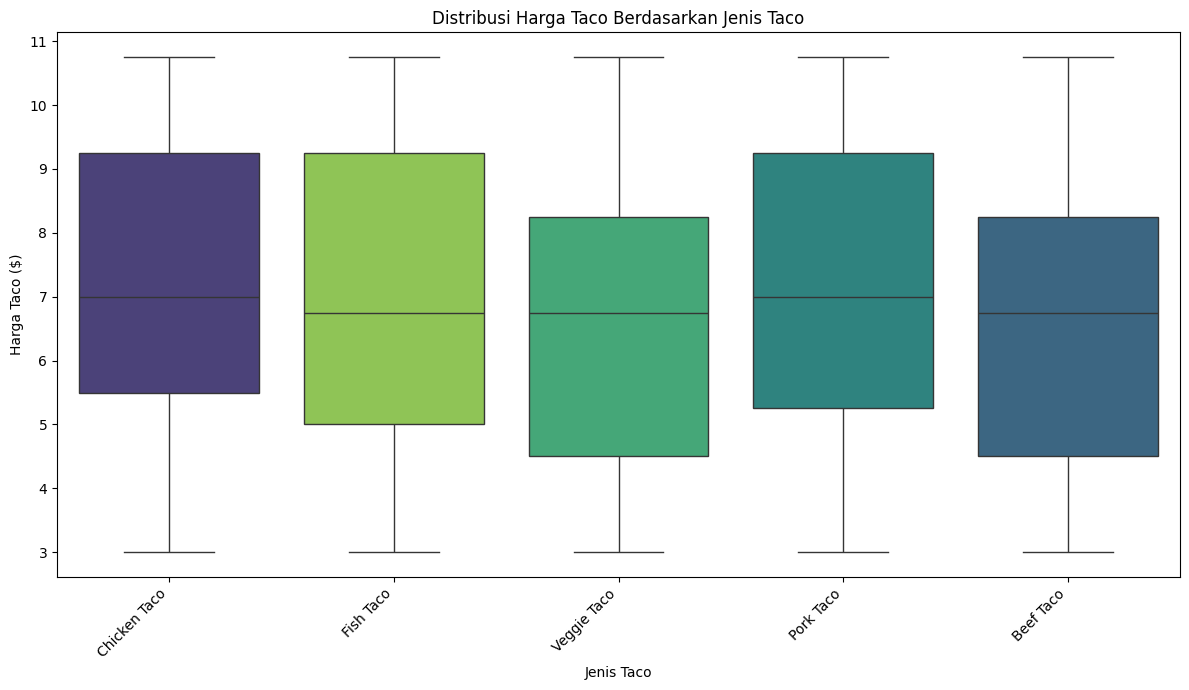

In [ ]:
jenis_taco_teratas = df['Taco Type'].value_counts().head(5).index
data_taco_teratas = df[df['Taco Type'].isin(jenis_taco_teratas)]

plt.figure(figsize=(12, 7))
sns.boxplot(x='Taco Type', y='Price ($)', data=data_taco_teratas, palette='viridis', order=jenis_taco_teratas, hue='Taco Type', legend=False)
plt.title('Distribusi Harga Taco Berdasarkan Jenis Taco')
plt.xlabel('Jenis Taco')
plt.ylabel('Harga Taco ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Dari boxplot ini terlihat bahwa harga taco pada setiap jenis taco tidak memiliki perbedaan yang terlalu jauh. Sebagian besar harga berada di kisaran sekitar 6 hingga 7 dolar untuk semua jenis taco seperti Chicken Taco, Fish Taco, Veggie Taco, Pork Taco, dan Beef Taco. Selain itu, rentang harga pada masing-masing jenis taco juga terlihat cukup mirip, yaitu mulai dari sekitar 3 hingga mendekati 11 dolar. Hal ini menunjukkan bahwa perbedaan jenis taco tidak terlalu memengaruhi harga secara signifikan. Berdasarkan kondisi tersebut, restoran dapat mempertahankan variasi menu taco yang ada karena setiap jenis taco memiliki kisaran harga yang relatif seimbang dan tetap menarik bagi pelanggan.

###**ScatterPlot**

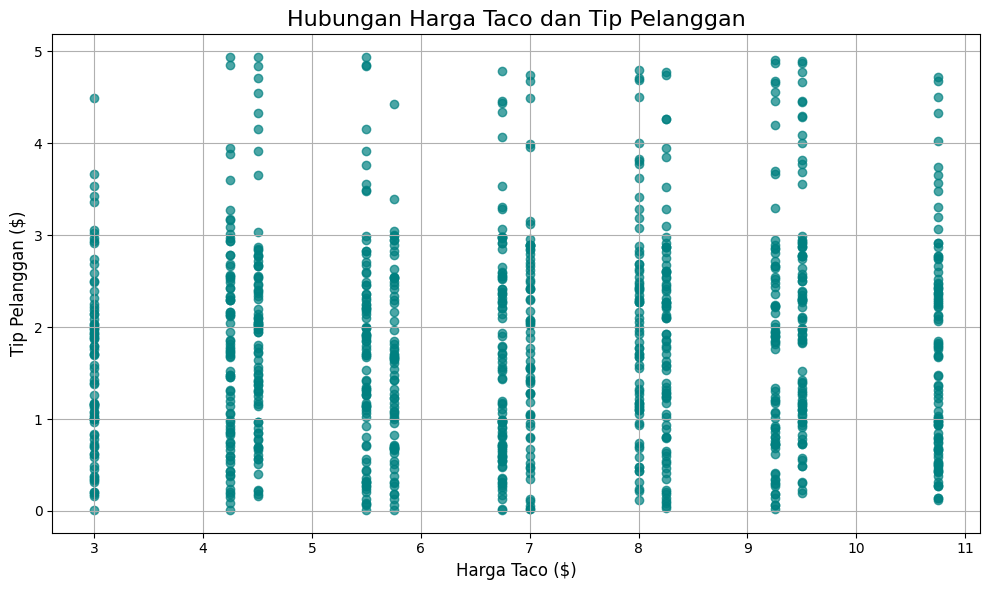

In [ ]:
plt.figure(figsize=(10, 6)) # Ukuran
plt.scatter(df['Price ($)'], df['Tip ($)'], alpha=0.7, color='teal') # Color (Warna)
plt.title('Hubungan Harga Taco dan Tip Pelanggan', fontsize=16) # Judul
plt.xlabel('Harga Taco ($)', fontsize=12) # X Keterangan
plt.ylabel('Tip Pelanggan ($)', fontsize=12) # Y Keterangan
plt.grid(True)
plt.tight_layout()
plt.show()

Dari scatter plot ini terlihat bahwa hubungan antara harga taco dan tip pelanggan memiliki korelasi yang kurang kuat, namun masih terlihat sedikit kecenderungan meningkat. Artinya, pada beberapa harga taco yang lebih tinggi terdapat tip yang lebih besar, tetapi pola tersebut tidak terlalu konsisten karena pada harga yang sama pelanggan dapat memberikan tip yang berbeda. Hal ini menunjukkan bahwa tip tidak hanya dipengaruhi oleh harga makanan, tetapi juga kemungkinan dipengaruhi oleh kualitas pelayanan atau kepuasan pelanggan. Oleh karena itu, restoran perlu meningkatkan kualitas layanan dan pengalaman pelanggan agar dapat mendorong pemberian tip yang lebih tinggi.

###**Bubble Chart**

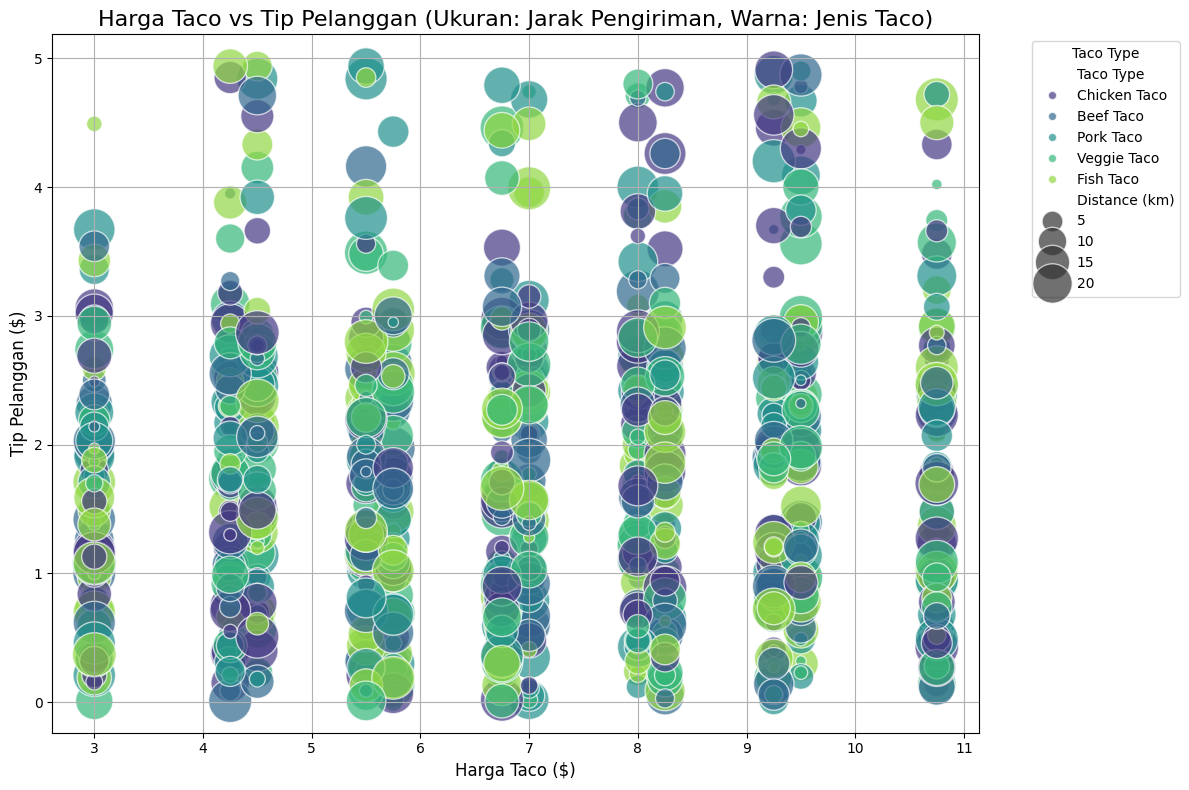

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Price ($)', y='Tip ($)', size='Distance (km)', hue='Taco Type', data=df, sizes=(50, 1000), alpha=0.7, palette='viridis')
plt.title('Harga Taco vs Tip Pelanggan (Ukuran: Jarak Pengiriman, Warna: Jenis Taco)', fontsize=16)
plt.xlabel('Harga Taco ($)', fontsize=12)
plt.ylabel('Tip Pelanggan ($)', fontsize=12)
plt.grid(True)
plt.legend(title='Taco Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Dari bubble chart ini terlihat hubungan antara harga taco dan tip pelanggan dengan ukuran bubble yang menunjukkan jarak pengiriman serta warna yang menunjukkan jenis taco. Secara umum hubungan antara harga dan tip masih terlihat kurang kuat, namun terdapat variasi tip pada berbagai jarak pengiriman dan jenis taco. Beberapa pesanan dengan jarak lebih jauh terlihat memiliki tip yang lebih besar. Hal ini menunjukkan bahwa selain harga, jarak pengiriman dan jenis taco juga dapat mempengaruhi tip yang diberikan pelanggan. Oleh karena itu, restoran perlu menjaga kualitas layanan pengantaran dan pelayanan kepada pelanggan agar kepuasan meningkat dan dapat mendorong pemberian tip yang lebih tinggi.

###**Heatmap**

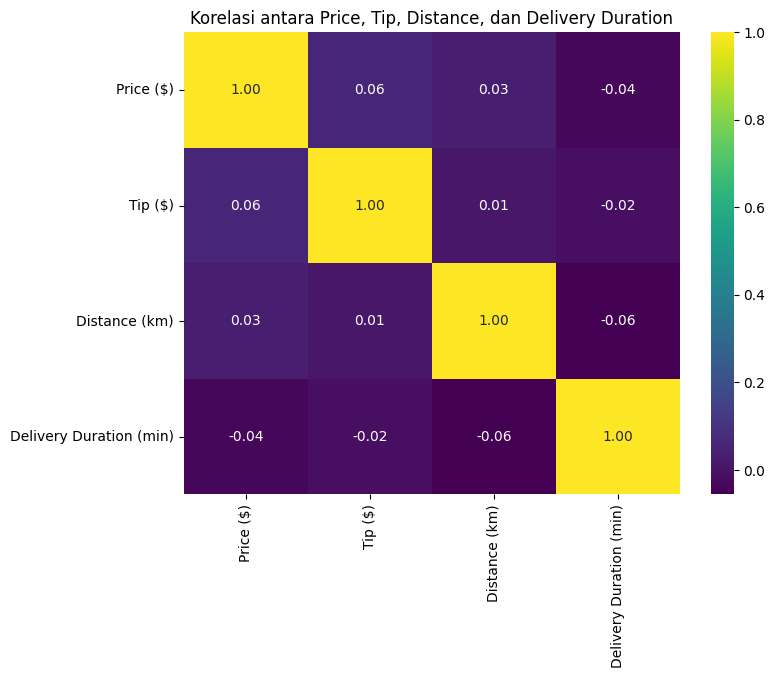

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Price ($)', 'Tip ($)', 'Distance (km)', 'Delivery Duration (min)']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Price, Tip, Distance, dan Delivery Duration')
plt.show()

Dari heatmap ini terlihat hubungan korelasi antar beberapa variabel seperti harga taco, tip pelanggan, jarak pengiriman, dan durasi pengiriman. Beberapa variabel menunjukkan hubungan yang cukup terlihat, misalnya jarak pengiriman dengan durasi pengiriman yang cenderung meningkat seiring bertambahnya jarak. Sementara itu hubungan antara harga taco dan tip pelanggan terlihat tidak terlalu kuat. Hal ini menunjukkan bahwa waktu pengiriman lebih dipengaruhi oleh jarak, sedangkan tip pelanggan kemungkinan juga dipengaruhi oleh faktor lain seperti kualitas pelayanan. Oleh karena itu, restoran dapat meningkatkan efisiensi pengiriman terutama untuk jarak yang lebih jauh agar kepuasan pelanggan tetap terjaga.

##**SIMPAN**

In [ ]:
output_path = "/content/drive/MyDrive/beljar avd/taco_sales_(2024-2025) (Bersih).xlsx"
df.to_excel(output_path, index=False)
print("File berhasil disimpan di (output_path)")

File berhasil disimpan di (output_path)
